# 2D Poisson Equation — Chebyshev Pseudospectral Direct Solver

This notebook solves the 2-D Poisson problem with homogeneous Dirichlet BCs
using a **Chebyshev pseudospectral** discretisation on a square domain.

## Problem

$$-\Delta u = f, \qquad (x,y)\in[-1,1]^2, \qquad u\big|_{\partial\Omega} = 0$$

### Exact solution

$$u(x,y) = (1-x^2)(1-y^2)$$

$$f(x,y) = -\Delta u = 2(1-y^2) + 2(1-x^2) = 2(2 - x^2 - y^2)$$

## Method — `ModelSpectralSolver` operator API

1. Build the Chebyshev model via `ModelSpectralSolver(bc="chebyshev")` on a **stationary** domain (no time axis → no integrator needed).
2. Register the **Kronecker-sum Laplacian** (with tau BCs) via `model.set_linear_op`:
   $$L = D_x^2 \otimes I_y + I_x \otimes D_y^2 \quad\in\mathbb{R}^{N^2\times N^2}$$
   Inside `set_linear_op`, `X = model.k = [D_x, D_y]` provides the per-dimension differentiation matrices.
3. Register the **RHS** (with tau BCs) via `model.set_source_op`:
   Inside `set_source_op`, `X = [x_{1d}, y_{1d}]` provides the 1-D collocation grids.

4. Call `model.solve()` which dispatches to `solve_stationary()`, assembling and solving $L\,u = f$ with `jnp.linalg.solve`.5. Compare with the exact solution.

## 1 — Import Required Libraries

In [1]:
import pinns

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## 2 — Physical Parameters and Time Grid

In [2]:
N = 32   # Chebyshev–Gauss–Lobatto points per dimension (includes endpoints)

## 3 — Build the Chebyshev Spectral Model

`ModelSpectralSolver` with `bc="chebyshev"` on a 2-D domain automatically:
- Places $N$ **Gauss–Lobatto nodes** per dimension on $[-1,1]$.
- Builds the **Chebyshev differentiation matrices** $D_x$, $D_y$ (shape $N\times N$), accessible via `model.k = [D_x, D_y]`.
- Returns `model.K2` as the list `[−D_x^2, −D_y^2]` (per-dimension negative-Laplacian matrices).

For a stationary solve (`DomainCubic` with no `time` argument) **no integrator is needed** — `ModelSpectralSolver` accepts `integrator=None` automatically.

In [3]:
domain = pinns.DomainCubic(
    space=[(-1.0, 1.0), (-1.0, 1.0)],
    # time=None (default) → stationary problem, no integrator required
)

model = pinns.ModelSpectralSolver(
    domain, ["u"], shape=N, bc="chebyshev"
)

# 2-D meshgrid of Gauss-Lobatto nodes (each shape (N, N))
x_gl = np.asarray(model.x)   # x-coordinates
y_gl = np.asarray(model.y)   # y-coordinates

print(f"Grid shape : {x_gl.shape}")
print(f"x range    : [{x_gl.min():.3f}, {x_gl.max():.3f}]")
print(f"y range    : [{y_gl.min():.3f}, {y_gl.max():.3f}]")

Grid shape : (32, 32)
x range    : [-1.000, 1.000]
y range    : [-1.000, 1.000]


## 4 — Register Operators via `set_linear_fn` / `set_source_fn`

Instead of building the full $N^2 \times N^2$ Kronecker matrix (`set_linear_op`), we register a **matrix-free action**:

- `set_linear_fn(fn)` — `fn(X, U, p)` returns $\{\text{name}: L(u)\}$ directly.  
  `X = _get_X() = [x_{1d}, y_{1d}]`; D-matrices are in `p["model"]["D"]`.
- `set_source_fn(fn)` — `fn(X, U, p)` returns the RHS.  
  Same `X`; state `U` is available (ignored here since source is linear).

The Laplacian **action** on the 2-D grid $u \in \mathbb{R}^{N\times N}$ is:

$$L(u) = D_x^2\, u + u\, D_y^2 \qquad O(N^3) \text{ vs } O(N^4) \text{ for the full Kronecker matrix}$$Tau BCs are applied **in-place** on the result array. `solve_stationary` detects `linear_fn` and uses **GMRES** (`jax.scipy.sparse.linalg.gmres`) instead of a direct solve.


In [4]:
Ng = x_gl.shape[0]   # Gauss-Lobatto points per dimension

def linear_fn(X, U, p):
    """Matrix-free Laplacian action.  X = [x_1d, y_1d]; D-matrices in p['model']['D']."""
    D_x, D_y = p["model"]["D"]
    D2x = D_x @ D_x
    D2y = D_y @ D_y
    u   = U["u"]                        # (Ng, Ng)
    # Δu = D²x u + u D²y  (row-major Kronecker action, O(Ng³))
    Lu  = D2x @ u + u @ D2y.T
    # Tau BCs: L(u)[boundary] = u[boundary]  (identity rows)
    Lu = Lu.at[0,  :].set(u[0,  :])
    Lu = Lu.at[-1, :].set(u[-1, :])
    Lu = Lu.at[:,  0].set(u[:,  0])
    Lu = Lu.at[:, -1].set(u[:, -1])
    return {"u": Lu}

def source_fn(X, U, p):
    """State-independent RHS.  X = [x_1d, y_1d]; U ignored (no nonlinearity)."""
    x_1d, y_1d = X[0], X[1]
    xx, yy = x_1d[:, None], y_1d[None, :]
    g = 2.0 * (2.0 - xx**2 - yy**2)   # Poisson RHS: −Δu = g  →  Δu = −g
    # solve_stationary solves L(u) = source → source = −g; BC rows = 0
    rhs = -g
    rhs = rhs.at[0,  :].set(0.0)
    rhs = rhs.at[-1, :].set(0.0)
    rhs = rhs.at[:,  0].set(0.0)
    rhs = rhs.at[:, -1].set(0.0)
    return {"u": rhs}

model.set_linear_fn(linear_fn)
model.set_source_fn(source_fn)


print(f"Ng (points/dim) : {Ng}")
print(f"No Kronecker matrix stored — matrix-free GMRES will be used")
print(f"Boundary nodes  : {4 * (Ng - 1)}")

Ng (points/dim) : 32
No Kronecker matrix stored — matrix-free GMRES will be used
Boundary nodes  : 124


## 5 — Solve via `model.solve()`

Because the domain has no time axis, `model.solve()` automatically dispatches to
`solve_stationary()`, which:
1. Calls `source_fn` with the zero state to build the tau-modified RHS $f_\tau$.
2. Detects that `linear_fn` is registered and uses **GMRES** (`jax.scipy.sparse.linalg.gmres`) with `linear_fn` as the matrix-vector product.
3. Returns `{"u": u}` shaped `(Ng, Ng)`.

No $N^2{\times}N^2$ matrix is ever allocated; each GMRES iteration costs $O(N^3)$.

In [5]:
# model.solve() dispatches to solve_stationary() for stationary domains
result = model.solve()
u_num  = result["u"]   # (Ng, Ng)

print(f"Max |u_num| = {float(jnp.max(jnp.abs(u_num))):.6f}   (expected ≈1.0)")

Max |u_num| = 0.975698   (expected ≈1.0)


In [6]:
# Fine uniform grid for smooth plotting
n_plot = 256
x_fine = np.linspace(-1.0, 1.0, n_plot)
y_fine = np.linspace(-1.0, 1.0, n_plot)
xx_fine, yy_fine = np.meshgrid(x_fine, y_fine, indexing="ij")

# Build (N, 2) query array [x, y] — apply() now takes X first, params optional
X_query = np.stack([xx_fine.ravel(), yy_fine.ravel()], axis=-1)  # (n_plot², 2)
u_flat  = model.apply(X_query)                                    # (n_plot², 1)
u_fine  = np.asarray(u_flat[:, 0]).reshape(n_plot, n_plot)

u_exact_fine = (1.0 - xx_fine**2) * (1.0 - yy_fine**2)
abs_err_fine = np.abs(u_fine - u_exact_fine)

print(f"Fine grid shape    : {u_fine.shape}")
print(f"Max absolute error : {abs_err_fine.max():.2e}")


Fine grid shape    : (256, 256)
Max absolute error : 2.46e-02


## 6 — Comparison with Exact Solution

$$u_{\text{exact}}(x,y) = (1-x^2)(1-y^2)$$

In [7]:
u_exact = (1.0 - x_gl**2) * (1.0 - y_gl**2)   # (N, N)

abs_err = jnp.abs(u_num - u_exact)
print(f"Max absolute error : {float(abs_err.max()):.2e}")
print(f"Max relative error : {float(abs_err.max() / jnp.abs(u_exact).max()):.2e}")

Max absolute error : 1.96e-02
Max relative error : 1.97e-02


## 7 — Visualization


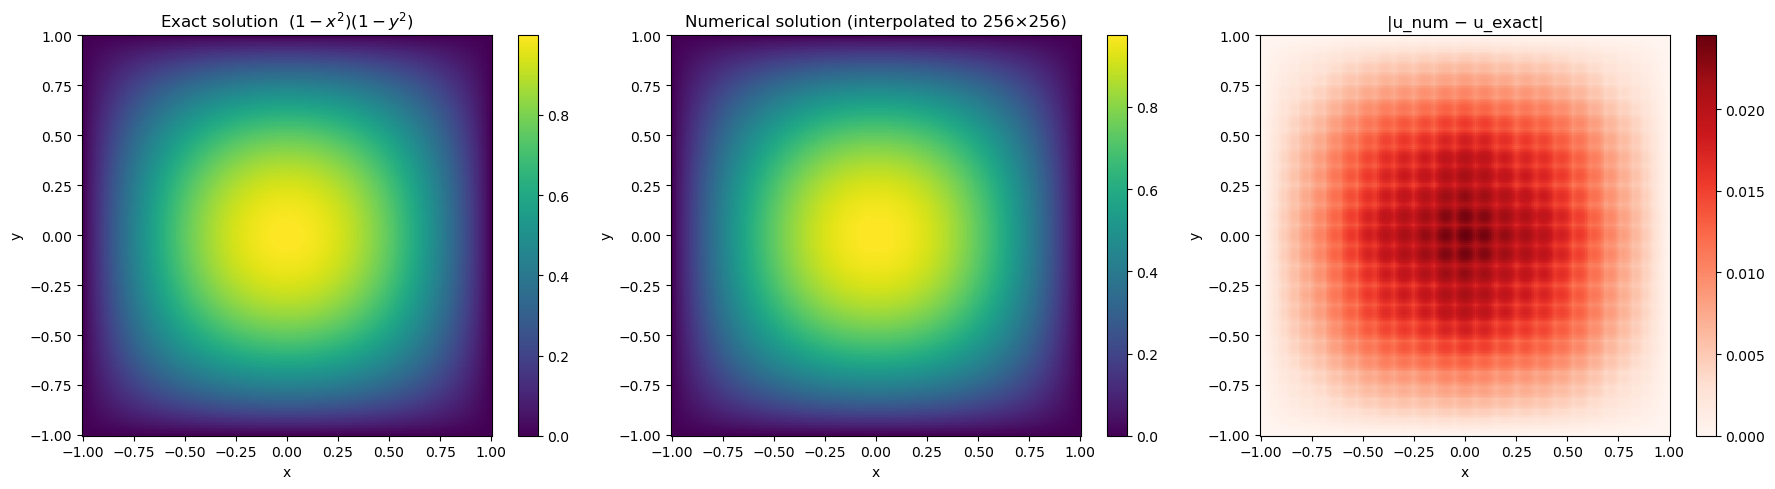

In [8]:
xx_fine, yy_fine = np.meshgrid(x_fine, y_fine, indexing="ij")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(xx_fine, yy_fine, u_exact_fine, cmap="viridis", shading="auto")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Exact solution  $(1-x^2)(1-y^2)$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(xx_fine, yy_fine, u_fine, cmap="viridis", shading="auto")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title(f"Numerical solution (interpolated to {n_plot}×{n_plot})")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(xx_fine, yy_fine, abs_err_fine, cmap="Reds", shading="auto")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_title("|u_num − u_exact|")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()
